# Heston vs Bates — NN Hedging Error Comparison (Calibrated Parameters)

Trains two `HestonHedgeNet` networks using the **calibrated parameters from Table 4.1** of the thesis (Kozyra 2006 calibration), then overlays the resulting P&L distributions for a fair apples-to-apples comparison.

Both models share the same hedge instruments (stock + variance swap), so `HestonHedgeNet`, `HestonCVaRLoss`, and `heston_trainer.train()` are reused unchanged for both.

| Model  | ν₀     | κ      | θ      | ξ      | ρ       | jumps |
|--------|--------|--------|--------|--------|---------|-------|
| Heston | 0.0654 | 0.6067 | 0.0707 | 0.2928 | −0.7571 | —     |
| Bates  | 0.0574 | 0.4963 | 0.0650 | 0.2286 | −0.9900 | μ_J=0.1791, σ_J=0.1346, λ=0.1382 |

* **α = 0.5** (ES₀.₅ loss) for both.
* Both networks are trained locally here and saved to `results/` (skipped on re-run if already saved).

In [40]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.heston_simulator import HestonParams, simulate as heston_simulate
from src.bates_simulator import BatesParams, BatesSimulator
from src.hedging.hedge_network import HestonHedgeNet
from src.hedging.loss import HestonCVaRLoss
from src.hedging.heston_trainer import train

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
RESULTS_DIR = Path('..') / 'results'

K     = 100.0
N     = 30
dt    = 1 / 365
ALPHA = 0.5

## 1 — Heston network (calibrated parameters, train locally)

In [41]:
HESTON_NET_PATH = RESULTS_DIR / 'heston_calib_ES05_network.pt'
HESTON_LOG_PATH = RESULTS_DIR / 'heston_calib_ES05_log.pt'

# Calibrated Heston parameters — Table 4.1 (Kozyra 2006)
heston_calib_params = HestonParams(
    S0=100.0,
    v0=0.0654,
    kappa=0.6067,
    theta=0.0707,
    xi=0.2928,
    rho=-0.7571,
    T=N * dt,
    N=N,
    M=100_000,
)

if HESTON_NET_PATH.exists():
    print('Calibrated Heston weights already exist — skipping simulation and training.')
    heston_log      = torch.load(HESTON_LOG_PATH, weights_only=False)
    vp_scale_heston = heston_log['vp_scale']
    p0_heston       = heston_log['p0']
    net_heston = HestonHedgeNet(N=N, width=20)
    net_heston.load_state_dict(torch.load(HESTON_NET_PATH, weights_only=True))
    net_heston.eval()
    print(f'Heston vp_scale : {vp_scale_heston:.4f}')
    print(f'Heston p0       : {p0_heston:.4f}')
else:
    print('Simulating 100 K calibrated Heston training paths ...')
    S_h, V_h, VP_h = heston_simulate(heston_calib_params, seed=19)
    print(f'  S: {S_h.shape}  V: {V_h.shape}  VarPrice: {VP_h.shape}')

    vp_scale_heston = 1.0 / float(VP_h[:, 0].mean())
    VP_h_scaled     = VP_h * vp_scale_heston
    print(f'  Heston vp_scale: {vp_scale_heston:.4f}')

    with torch.no_grad():
        p0_heston = float(torch.clamp(S_h[:, -1] - K, min=0.0).mean())
    print(f'  Heston call price (MC): {p0_heston:.4f}')

    net_heston = HestonHedgeNet(N=N, width=20)
    loss_fn_h  = HestonCVaRLoss(K=K, alpha=ALPHA)

    # lr=5e-3: the calibrated params (ξ=0.2928, near Feller) produce a much smoother
    # loss landscape than the He et al. params (ξ=2.0) that train_heston.py was
    # designed for.  The higher lr=5e-2 overshoots on the calibrated problem;
    # 5e-3 matches what train_adv_heston.py uses for HestonHedgeNet.
    print(f'Training Heston ES_{ALPHA} network (700 epochs, lr=5e-3) ...')
    losses_h, p0_h_tensor = train(
        net_heston,
        S_h,
        V_h,
        VP_h_scaled,
        loss_fn_h,
        p0_init   = p0_heston,
        n_epochs  = 700,
        batch_size= 10_000,
        lr        = 5e-3,   # lower than He et al. (5e-2) — calibrated params are smoother
        log_every = 100,
    )
    p0_heston    = p0_h_tensor.item()
    losses_heston = losses_h
    net_heston.eval()

    torch.save(net_heston.cpu().state_dict(), HESTON_NET_PATH)
    torch.save(
        {'losses': losses_h, 'p0': p0_heston, 'alpha': ALPHA,
         'params': vars(heston_calib_params), 'vp_scale': vp_scale_heston},
        HESTON_LOG_PATH,
    )
    print(f'Heston network saved.  Final p0 = {p0_heston:.4f}')

Simulating 100 K calibrated Heston training paths ...
  S: torch.Size([100000, 31])  V: torch.Size([100000, 31])  VarPrice: torch.Size([100000, 31])
  Heston vp_scale: 185.6657
  Heston call price (MC): 2.9002
Training Heston ES_0.5 network (700 epochs, lr=5e-3) ...
epoch    0  loss=6.824783  p0=2.8952
epoch  100  loss=3.290521  p0=2.8747
epoch  200  loss=3.265266  p0=2.8714
epoch  300  loss=3.256648  p0=2.8789
epoch  400  loss=3.244925  p0=2.8792
epoch  500  loss=3.242197  p0=2.8792
epoch  600  loss=3.245056  p0=2.8794
epoch  699  loss=3.249836  p0=2.8793
Heston network saved.  Final p0 = 2.8793


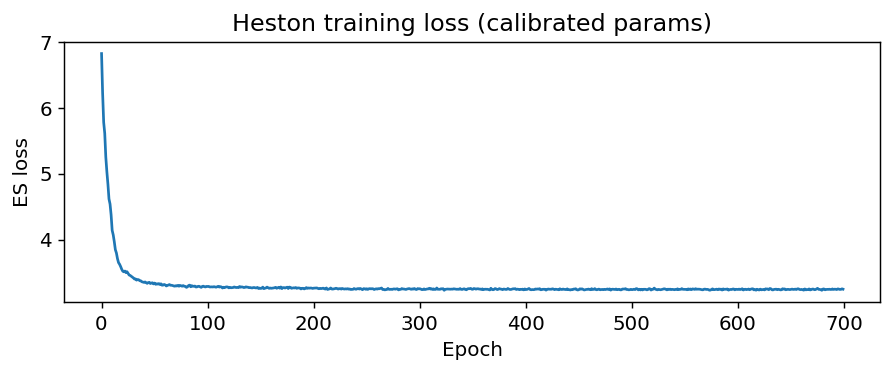

First loss: 6.8248  →  Last loss: 3.2498


In [42]:
# Training loss curve — verify convergence (only plotted when trained this session)
if 'losses_heston' in dir():
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(losses_heston)
    ax.set_xlabel('Epoch'); ax.set_ylabel('ES loss')
    ax.set_title('Heston training loss (calibrated params)')
    plt.tight_layout(); plt.show()
    print(f'First loss: {losses_heston[0]:.4f}  →  Last loss: {losses_heston[-1]:.4f}')

## 2 — Bates network (calibrated parameters, train locally)

Uses the same `HestonHedgeNet` architecture and `heston_trainer.train()` — both Bates and Heston share stock + variance-swap as hedge instruments, so no new code is needed.

In [43]:
BATES_NET_PATH = RESULTS_DIR / 'bates_ES05_network.pt'
BATES_LOG_PATH = RESULTS_DIR / 'bates_ES05_log.pt'

bates_params = BatesParams(
    S0=100.0,
    v0=0.0574,
    kappa=0.4963,
    theta=0.0650,
    xi=0.2286,
    rho=-0.990,
    mu_J=0.1791,
    sigma_J=0.1346,
    lam=0.1382,
    T=N * dt,
    N=N,
    M=100_000,
)

if BATES_NET_PATH.exists():
    print('Bates weights already exist — skipping simulation and training.')
    bates_log       = torch.load(BATES_LOG_PATH, weights_only=False)
    vp_scale_bates  = bates_log['vp_scale']
    p0_bates        = bates_log['p0']
    net_bates = HestonHedgeNet(N=N, width=20)
    net_bates.load_state_dict(torch.load(BATES_NET_PATH, weights_only=True))
    net_bates.eval()
    print(f'Bates vp_scale : {vp_scale_bates:.4f}')
    print(f'Bates p0       : {p0_bates:.4f}')
else:
    print('Simulating 100 K Bates training paths ...')
    sim   = BatesSimulator(bates_params)
    S_b, V_b, VP_b = sim.simulate(seed=42)
    print(f'  S: {S_b.shape}  V: {V_b.shape}  VarPrice: {VP_b.shape}')

    vp_scale_bates = 1.0 / float(VP_b[:, 0].mean())
    VP_b_scaled    = VP_b * vp_scale_bates
    print(f'  Bates vp_scale: {vp_scale_bates:.4f}')

    with torch.no_grad():
        p0_bates = float(torch.clamp(S_b[:, -1] - K, min=0.0).mean())
    print(f'  Bates call price (MC): {p0_bates:.4f}')

Bates weights already exist — skipping simulation and training.
Bates vp_scale : 211.3996
Bates p0       : 2.7197


In [44]:
if not BATES_NET_PATH.exists():
    net_bates = HestonHedgeNet(N=N, width=20)
    loss_fn   = HestonCVaRLoss(K=K, alpha=ALPHA)

    print(f'Training Bates ES_{ALPHA} network (700 epochs) ...')
    losses_b, p0_b_tensor = train(
        net_bates,
        S_b,
        V_b,
        VP_b_scaled,
        loss_fn,
        p0_init   = p0_bates,
        n_epochs  = 700,
        batch_size= 10_000,
        lr        = 5e-2,
        log_every = 100,
    )
    p0_bates = p0_b_tensor.item()
    net_bates.eval()

    torch.save(net_bates.cpu().state_dict(), BATES_NET_PATH)
    torch.save(
        {'losses': losses_b, 'p0': p0_bates, 'alpha': ALPHA,
         'params': vars(bates_params), 'vp_scale': vp_scale_bates},
        BATES_LOG_PATH,
    )
    print(f'Bates network saved.  Final p0 = {p0_bates:.4f}')

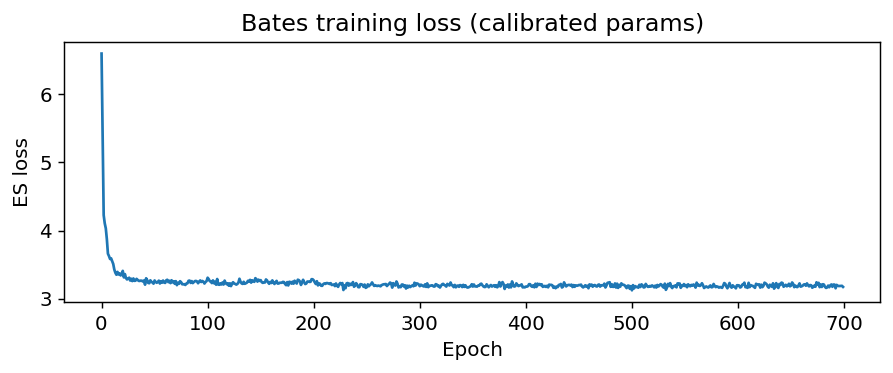

First loss: 6.5912  →  Last loss: 3.1749


In [45]:
# Training loss curve — verify convergence (only plotted when trained this session)
if 'losses_b' in dir():
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(losses_b)
    ax.set_xlabel('Epoch'); ax.set_ylabel('ES loss')
    ax.set_title('Bates training loss (calibrated params)')
    plt.tight_layout(); plt.show()
    print(f'First loss: {losses_b[0]:.4f}  →  Last loss: {losses_b[-1]:.4f}')

## 3 — Evaluate on fresh test paths

In [46]:
def compute_pl(net, S, V, VarPrice_scaled, p0):
    """P&L = p0 + Σ_t(δ_S·ΔS + δ_V·ΔVP_scaled) − C_T  →  shape (M,)"""
    net.eval()
    with torch.no_grad():
        x = torch.cat([
            torch.log(S[:, :-1]).unsqueeze(-1),
            V[:, :-1].unsqueeze(-1),
        ], dim=-1)                              # (M, N, 2)
        holding = net(x)                        # (M, N, 2)
    dS  = S[:, 1:]  - S[:, :-1]
    dVP = VarPrice_scaled[:, 1:] - VarPrice_scaled[:, :-1]
    pnl = (holding[:, :, 0] * dS + holding[:, :, 1] * dVP).sum(dim=1)
    payoff = torch.clamp(S[:, -1] - K, min=0.0)
    return (p0 + pnl - payoff).cpu()


def pl_stats(pl, label):
    arr = pl.numpy()
    levels = [0.99, 0.95, 0.90, 0.80, 0.50]
    qs     = [np.quantile(arr, 1 - v) for v in levels]
    print(
        f"{label:<24}  mean={arr.mean():.4f}  "
        + '  '.join(f'VaR{int(v*100)}={q:.4f}' for v, q in zip(levels, qs))
    )
    return arr.mean(), qs

In [47]:
# ---- Heston test paths (calibrated params, seed=20) ----
heston_test_params = HestonParams(
    S0=heston_calib_params.S0, v0=heston_calib_params.v0,
    kappa=heston_calib_params.kappa, theta=heston_calib_params.theta,
    xi=heston_calib_params.xi, rho=heston_calib_params.rho,
    T=heston_calib_params.T, N=heston_calib_params.N, M=100_000,
)
S_h_test, V_h_test, VP_h_test = heston_simulate(heston_test_params, seed=20)
VP_h_test_scaled = VP_h_test * vp_scale_heston
print(f'Heston test paths: {S_h_test.shape}')

pl_heston = compute_pl(net_heston, S_h_test, V_h_test, VP_h_test_scaled, p0_heston)
pl_stats(pl_heston, 'Heston NN hedge')

Heston test paths: torch.Size([100000, 31])
Heston NN hedge           mean=-0.0312  VaR99=-1.3818  VaR95=-0.8371  VaR90=-0.6084  VaR80=-0.3749  VaR50=-0.0092


(np.float32(-0.031211695),
 [np.float32(-1.3817608),
  np.float32(-0.8371297),
  np.float32(-0.6084368),
  np.float32(-0.3748551),
  np.float32(-0.009188414)])

In [48]:
# ---- Bates test paths (seed=99, fresh draw) ----
bates_test_params = BatesParams(
    S0=bates_params.S0, v0=bates_params.v0,
    kappa=bates_params.kappa, theta=bates_params.theta,
    xi=bates_params.xi, rho=bates_params.rho,
    mu_J=bates_params.mu_J, sigma_J=bates_params.sigma_J, lam=bates_params.lam,
    T=bates_params.T, N=bates_params.N, M=100_000,
)
S_b_test, V_b_test, VP_b_test = BatesSimulator(bates_test_params).simulate(seed=99)
VP_b_test_scaled = VP_b_test * vp_scale_bates
print(f'Bates test paths: {S_b_test.shape}')

pl_bates = compute_pl(net_bates, S_b_test, V_b_test, VP_b_test_scaled, p0_bates)
pl_stats(pl_bates, 'Bates NN hedge')

Bates test paths: torch.Size([100000, 31])
Bates NN hedge            mean=-0.0946  VaR99=-1.5797  VaR95=-0.7942  VaR90=-0.5599  VaR80=-0.3404  VaR50=-0.0015


(np.float32(-0.09457038),
 [np.float32(-1.5796568),
  np.float32(-0.79422873),
  np.float32(-0.5599259),
  np.float32(-0.34038466),
  np.float32(-0.0015462637)])

## 4 — Overlapping P&L histograms

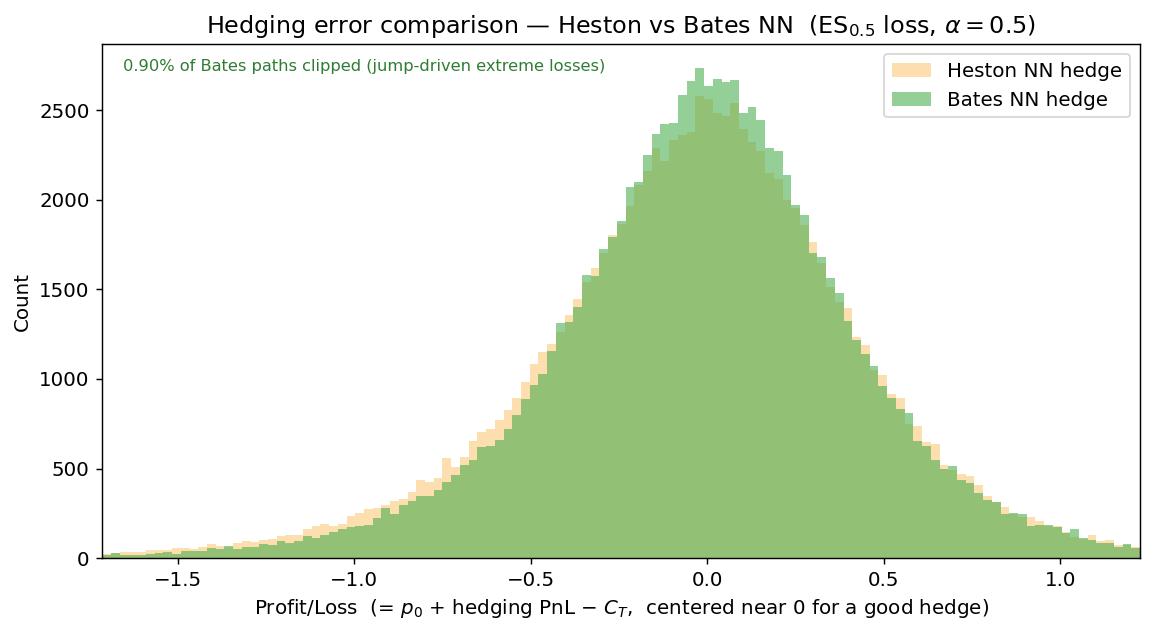

In [49]:
arr_h = pl_heston.numpy()
arr_b = pl_bates.numpy()

# Clip x-axis to 1st–99th percentile so rare jump outliers don't squash the bulk.
# (Bates can produce losses of -50 to -80 from large upward jumps that outpace
# the pre-set delta; those extreme paths are counted in the tail annotation below.)
lo = min(np.percentile(arr_h, 1.0), np.percentile(arr_b, 1.0))
hi = max(np.percentile(arr_h, 99.0), np.percentile(arr_b, 99.0))
margin = 0.05 * (hi - lo)
xlim   = (lo - margin, hi + margin)
bins   = np.linspace(*xlim, 120)

# Fraction of Bates paths outside the visible range (jump-driven extreme losses)
pct_clipped = 100 * (arr_b < xlim[0]).mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(arr_h, bins=bins, alpha=0.6, color='#FAC87A', label='Heston NN hedge')
ax.hist(arr_b, bins=bins, alpha=0.6, color='#4CAF50', label='Bates NN hedge')
ax.set_xlim(xlim)
ax.set_xlabel('Profit/Loss  (= $p_0$ + hedging PnL $-$ $C_T$,  centered near 0 for a good hedge)')
ax.set_ylabel('Count')
ax.set_title(f'Hedging error comparison — Heston vs Bates NN  (ES$_{{{ALPHA}}}$ loss, $\\alpha={ALPHA}$)')
ax.legend()
if pct_clipped > 0:
    ax.text(0.02, 0.97,
            f'{pct_clipped:.2f}% of Bates paths clipped (jump-driven extreme losses)',
            transform=ax.transAxes, va='top', fontsize=9, color='#2e7d32')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'heston_vs_bates_comparison.png', bbox_inches='tight')
plt.show()

## 5 — Summary statistics

In [50]:
var_levels = [0.99, 0.95, 0.90, 0.80, 0.50]
header = f"{'Model':<24} {'Mean':>8}" + "".join(f"{'VaR'+str(int(v*100)):>10}" for v in var_levels)
print(header)
print('-' * len(header))

for label, arr in [('Heston NN hedge', arr_h), ('Bates NN hedge', arr_b)]:
    qs  = [np.quantile(arr, 1 - v) for v in var_levels]
    row = f"{label:<24} {arr.mean():>8.4f}" + "".join(f"{q:>10.4f}" for q in qs)
    print(row)

Model                        Mean     VaR99     VaR95     VaR90     VaR80     VaR50
-----------------------------------------------------------------------------------
Heston NN hedge           -0.0312   -1.3818   -0.8371   -0.6084   -0.3749   -0.0092
Bates NN hedge            -0.0946   -1.5797   -0.7942   -0.5599   -0.3404   -0.0015
